# Concrete Dataset

- Bu proje, Gradient Boosting'te öğrendiğim teorik bilgileri uygulamaya dökmek amacıyla hazırlanmıştır.

- **Amaç**, beton karışımında kullanılan malzeme miktarları ve beton yaşı gibi özelliklerden yararlanarak betonun basınç dayanımını (MPa) tahmin etmektir

- Öncelik olarak **Gradient Boosting Regressor** kullanılmış ardından farklı regresyon modelleri ile performans karşılaştırması yapılmıştır.

## Model Performansları

| Model                          |   R² Score |
| ------------------------------ | ---------: |
| Gradient Boosting (Raw Target) |     89.17% |
| Gradient Boosting (√Target)    | **91.23%** |
| RandomForestRegressor          |     89.64% |
| DecisionTreeRegressor          |     85.79% |
| AdaBoostRegressor              |     78.84% |
| KNeighborsRegressor            |     74.04% |
| LinearRegression               |     63.83% |
| Ridge                          |     63.76% |
| Lasso                          |     61.51% |
| SVR                            |     56.75% |

### Çıkarımlar

* **En iyi performans %91.23 R² ile karekök dönüşümü uygulanmış Gradient Boosting modeli tarafından elde edilmiştir.**
* Hedef değişken dönüşümü, büyük değerlerin etkisini azaltarak modelin residual yapısını daha dengeli öğrenmesine yardımcı olmuştur.
* Ağaç tabanlı algoritmalar (Gradient Boosting, Random Forest, Decision Tree), doğrusal modellere kıyasla belirgin şekilde daha başarılı sonuçlar vermiştir.
* Bu sonuçlar, beton dayanımı problemindeki ilişkilerin tamamen doğrusal olmadığını ve ensemble tabanlı ağaç modellerinin karmaşık örüntüleri daha iyi yakalayabildiğini göstermektedir.


| Feature | Description |
|----------|-------------|
| Cement | Amount of cement used in the concrete mixture (kg/m³). |
| Blast Furnace Slag | Ground granulated blast furnace slag used as a supplementary cementitious material (kg/m³). |
| Fly Ash | Fly ash added to improve workability and durability (kg/m³). |
| Water | Amount of water in the concrete mixture (kg/m³). |
| Superplasticizer | Chemical admixture used to increase workability while reducing water content (kg/m³). |
| Coarse Aggregate | Amount of coarse aggregate (gravel/crushed stone) in the mixture (kg/m³). |
| Fine Aggregate | Amount of fine aggregate (sand) in the mixture (kg/m³). |
| Age | Age of the concrete specimen at the time of strength measurement (days). |
| Strength | Compressive strength of the concrete (MPa). *(Target Variable)* |

| Özellik                | Türkçe Karşılığı   | Açıklama                                                                              |
| ---------------------- | ------------------ | ------------------------------------------------------------------------------------- |
| Çimento                | Cement             | Beton karışımında kullanılan çimento miktarı (kg/m³).                                 |
| Yüksek Fırın Cürufu    | Blast Furnace Slag | Çimentonun bir kısmını ikame eden mineral katkı malzemesi (kg/m³).                    |
| Uçucu Kül              | Fly Ash            | Betonun işlenebilirliğini ve dayanıklılığını artıran mineral katkı malzemesi (kg/m³). |
| Su                     | Water              | Beton karışımında kullanılan su miktarı (kg/m³).                                      |
| Süper Akışkanlaştırıcı | Superplasticizer   | Betonun akışkanlığını artıran kimyasal katkı malzemesi (kg/m³).                       |
| İri Agrega             | Coarse Aggregate   | Çakıl veya kırmataş gibi iri taneli agrega miktarı (kg/m³).                           |
| İnce Agrega            | Fine Aggregate     | Kum gibi ince taneli agrega miktarı (kg/m³).                                          |
| Yaş                    | Age                | Beton numunesinin basınç dayanımının ölçüldüğü yaş (gün).                             |
| Basınç Dayanımı        | Strength           | Betonun basınç dayanımı (MPa). **(Hedef Değişken)**                                   |


In [478]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from math import ceil


warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.figsize"] = (16, 8)
sns.set_style("darkgrid")

In [479]:
df = pd.read_csv("concrete_data.csv")

In [480]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0000,0.0000,0.0000,162.0000,2.5000,1040.0000,676.0000,28,79.9900
1,540.0000,0.0000,0.0000,162.0000,2.5000,1055.0000,676.0000,28,61.8900
2,332.5000,142.5000,0.0000,228.0000,0.0000,932.0000,594.0000,270,40.2700
3,332.5000,142.5000,0.0000,228.0000,0.0000,932.0000,594.0000,365,41.0500
4,198.6000,132.4000,0.0000,192.0000,0.0000,978.4000,825.5000,360,44.3000


In [481]:
df.dtypes

Cement                float64
Blast Furnace Slag    float64
Fly Ash               float64
Water                 float64
Superplasticizer      float64
Coarse Aggregate      float64
Fine Aggregate        float64
Age                     int64
Strength              float64
dtype: object

In [482]:
print(f"Shape : {df.shape}")

Shape : (1030, 9)


In [483]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.0000,1030.0000,1030.0000,1030.0000,1030.0000,1030.0000,1030.0000,1030.0000,1030.0000
mean,281.1679,73.8958,54.1883,181.5673,6.2047,972.9189,773.5805,45.6621,35.8180
std,104.5064,86.2793,63.9970,21.3542,5.9738,77.7540,80.1760,63.1699,16.7057
min,102.0000,0.0000,0.0000,121.8000,0.0000,801.0000,594.0000,1.0000,2.3300
25%,192.3750,0.0000,0.0000,164.9000,0.0000,932.0000,730.9500,7.0000,23.7100
50%,272.9000,22.0000,0.0000,185.0000,6.4000,968.0000,779.5000,28.0000,34.4450
75%,350.0000,142.9500,118.3000,192.0000,10.2000,1029.4000,824.0000,56.0000,46.1350
max,540.0000,359.4000,200.1000,247.0000,32.2000,1145.0000,992.6000,365.0000,82.6000


In [484]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [485]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [486]:
# Veri seti 8 bağımsız 1 bağımlı değişken olmak  üzere toplamda 9 kolondan, ayrıdca toplamda 1030 satırdan oluşmaktadır.

# Veri setindeki değişkenlerin veri tiplerinde herhangi bir hataya rastlanmamıştır.

# Veri setinde eksik veri gözlemlenmemiştir.

#Blast Furncae Slag değişkeninin ortalama(mean) değeri değişkenin medyan(%50) değerinden yaklaşık 3 kat daha büyüktür.
#Bu gözlem değişkenin çarpık bir dağılıma sahip olduğuna işaret etse de bu değişken projenin EDA kısmında incelenecektir.

## Exploratory Data Analysis (EDA) - Keşifçi Veri Analizi

**Analysis of the Target variable - Hedef değişkeninin analizi**

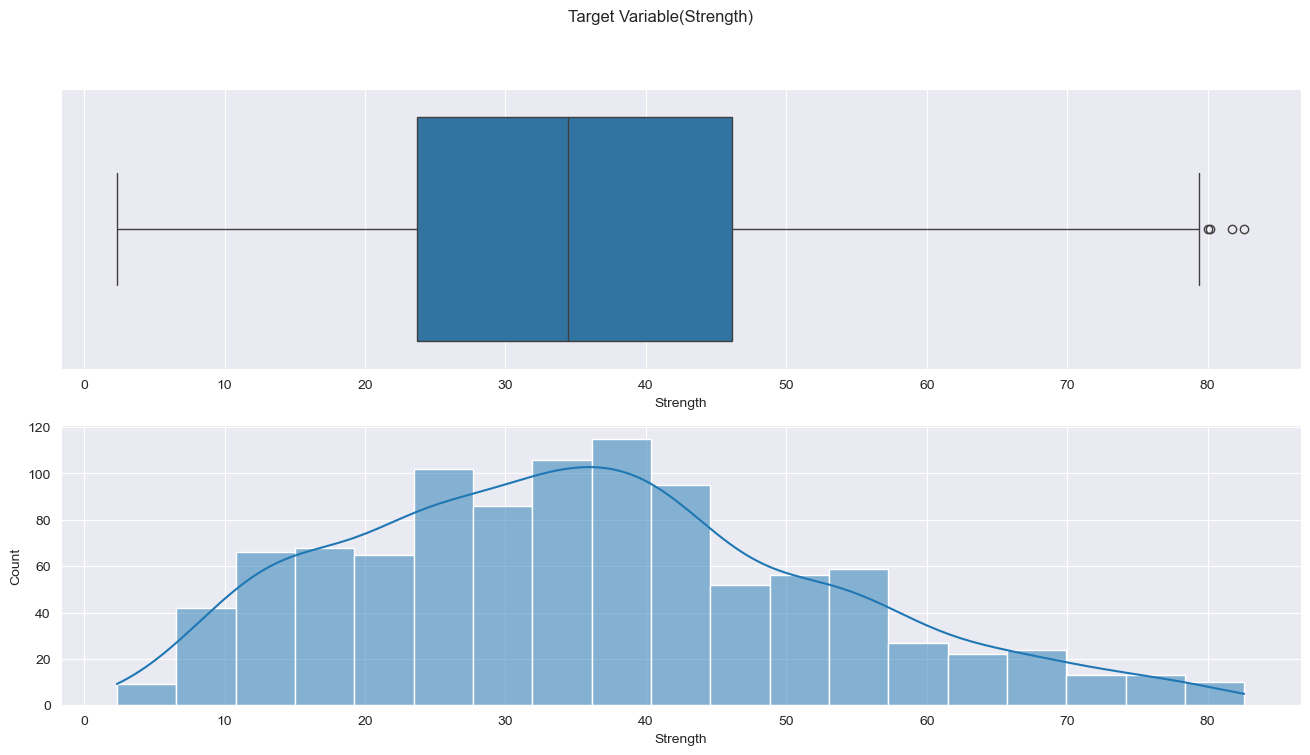

In [487]:
fig, axis = plt.subplots(2, 1)
axis = axis.ravel()

sns.boxplot(
    data= df,
    x = "Strength",
    ax = axis[0]
)

sns.histplot(
    data= df,
    x= "Strength",
    kde= True,
    ax= axis[1]
)

plt.suptitle("Target Variable(Strength)")
plt.show()

In [488]:
q1, q2, q3 = np.quantile(df["Strength"], [0.25, 0.50, 0.75])

mean = df["Strength"].mean()

median = q2

iqr = q3 - q1

upper_bound = q3 + (iqr * 1.5)

lower_bound = q1 - (iqr * 1.5)
lower_bound = lower_bound if lower_bound > 0 else 0


kurtosis = df["Strength"].kurt()
skewness = df["Strength"].skew()

print(f"Inter Quantile Range(Çeyreklikler Arası Mesafe) : {iqr:.3f}")
print(f"Q1                         : {q1:.3f}")
print(f"Median(Medyan)(Q2)         : {median:.3f}")
print(f"Q3                         : {q3:.3f}")
print(f"Median(Medyan)             : {median:.3f}")
print(f"Upper Bound(Üst Bıyık)     : {upper_bound:.3f}")
print(f"Lower Bound(Alt Bıyık)     : {lower_bound:.3f}")
print(f"Kurtosis(Basıklık)         : {kurtosis:.3f}")
print(f"Skewness(Çarpıklık)        : {skewness:.3f}")

Inter Quantile Range(Çeyreklikler Arası Mesafe) : 22.425
Q1                         : 23.710
Median(Medyan)(Q2)         : 34.445
Q3                         : 46.135
Median(Medyan)             : 34.445
Upper Bound(Üst Bıyık)     : 79.773
Lower Bound(Alt Bıyık)     : 0.000
Kurtosis(Basıklık)         : -0.314
Skewness(Çarpıklık)        : 0.417


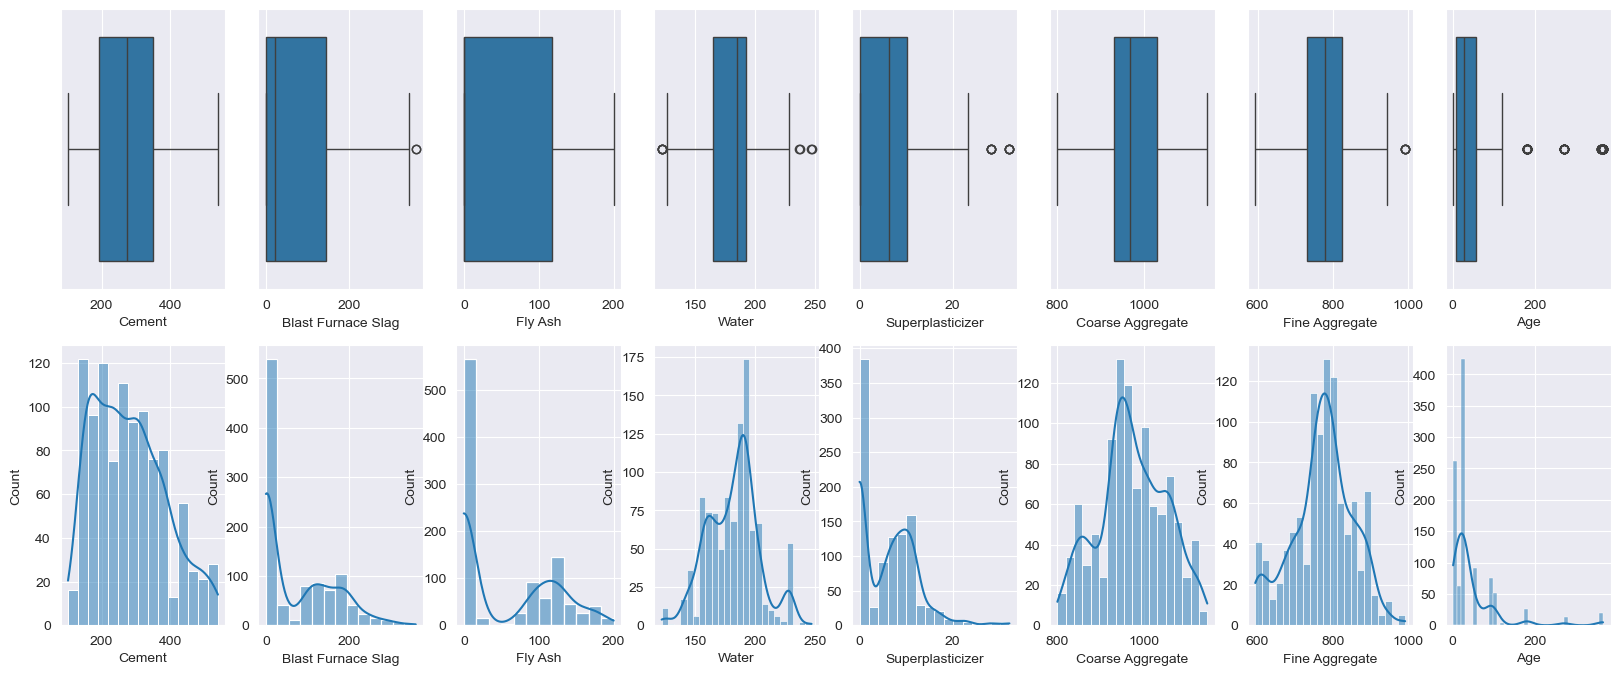

In [489]:
columns = df.drop("Strength", axis= 1).columns

row = 2
col = len(columns)

fig, axis = plt.subplots(row, col, figsize = (20, 8))

for index, column in enumerate(columns):
    sns.boxplot(
        data= df,
        x = column,
        ax = axis[0][index]
    )

    sns.histplot(
        data= df,
        x= column,
        kde= True,
        ax= axis[1][index]
    )

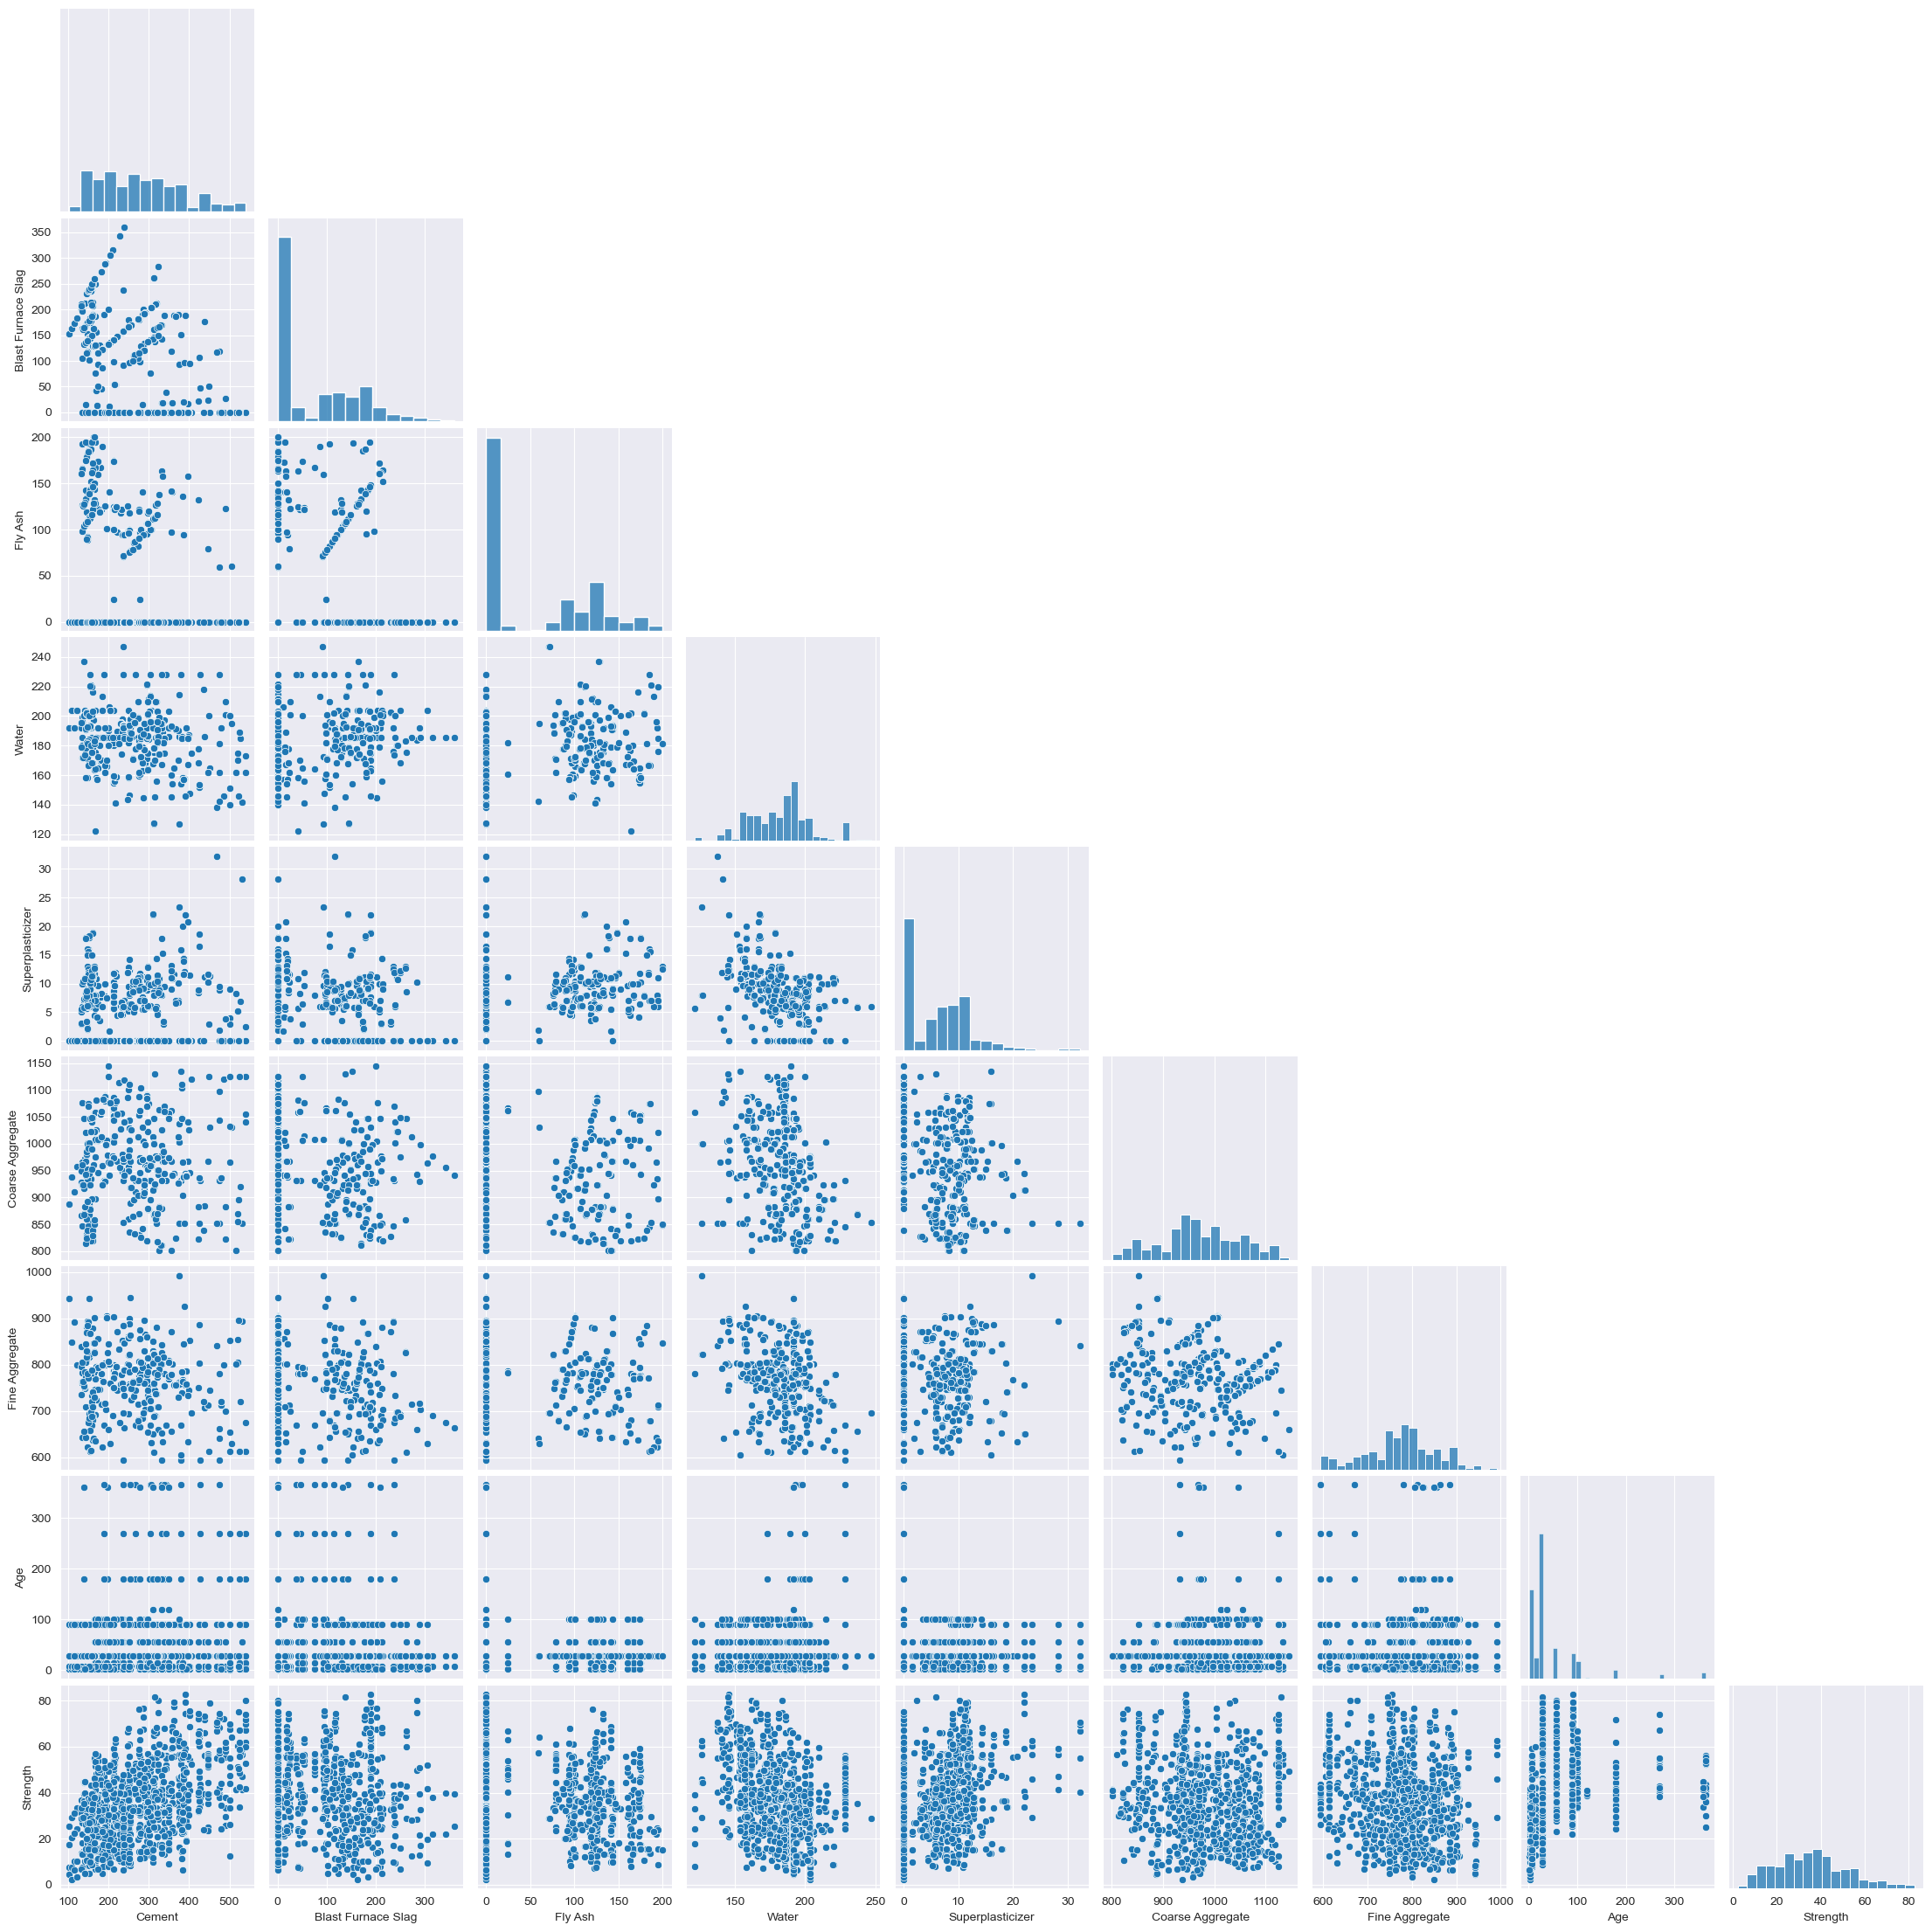

In [490]:
sns.pairplot(df, corner= True)

plt.show()

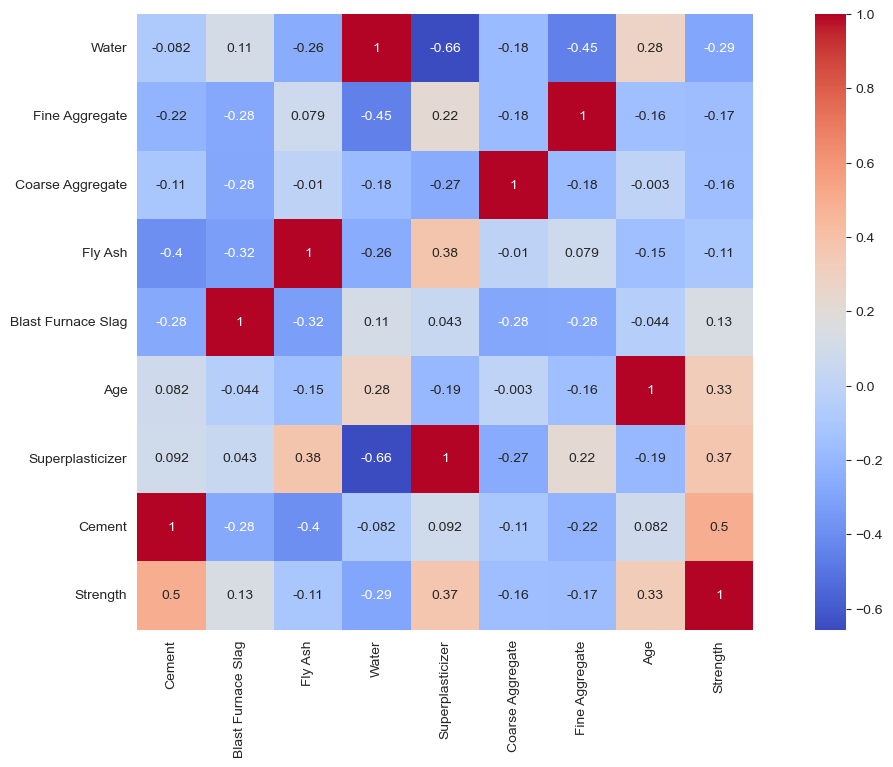

In [491]:
corr = df.corr(numeric_only= True).sort_values(by= "Strength")

sns.heatmap(corr, cmap= "coolwarm", square= True, annot= True)
plt.show()

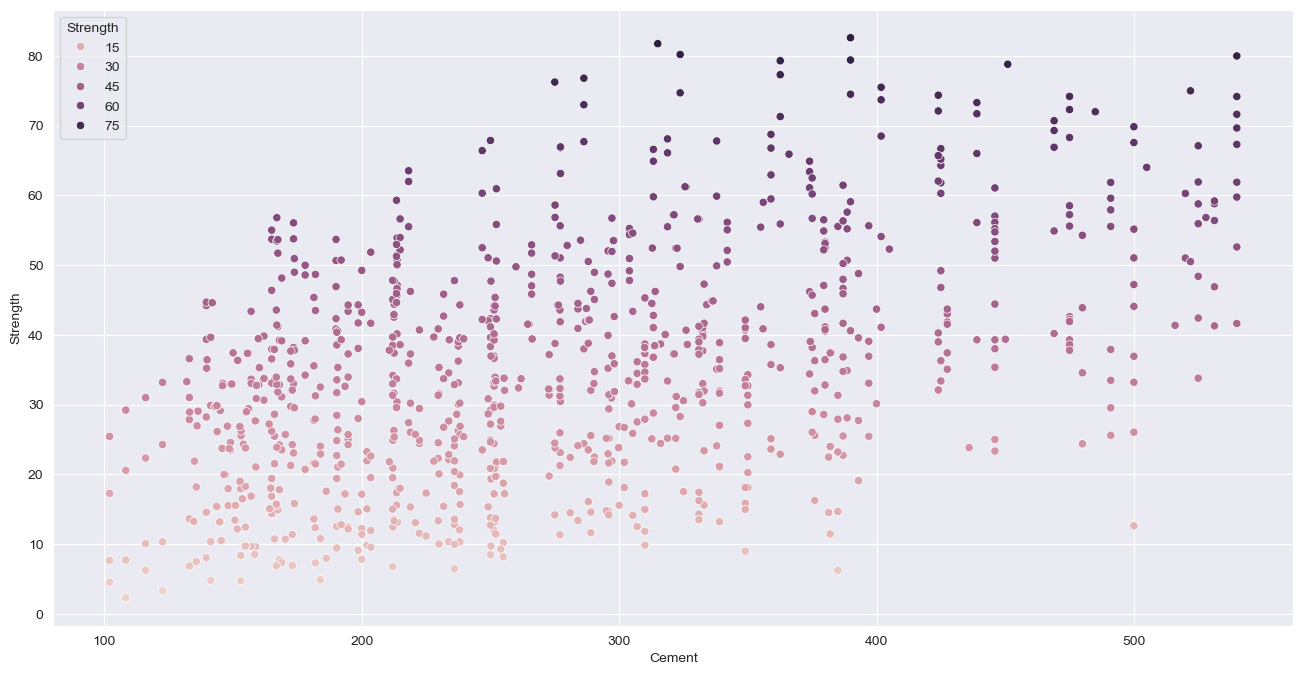

In [492]:
sns.scatterplot(
    data= df,
    x= "Cement",
    y= "Strength",
    hue= "Strength"
)

plt.show()

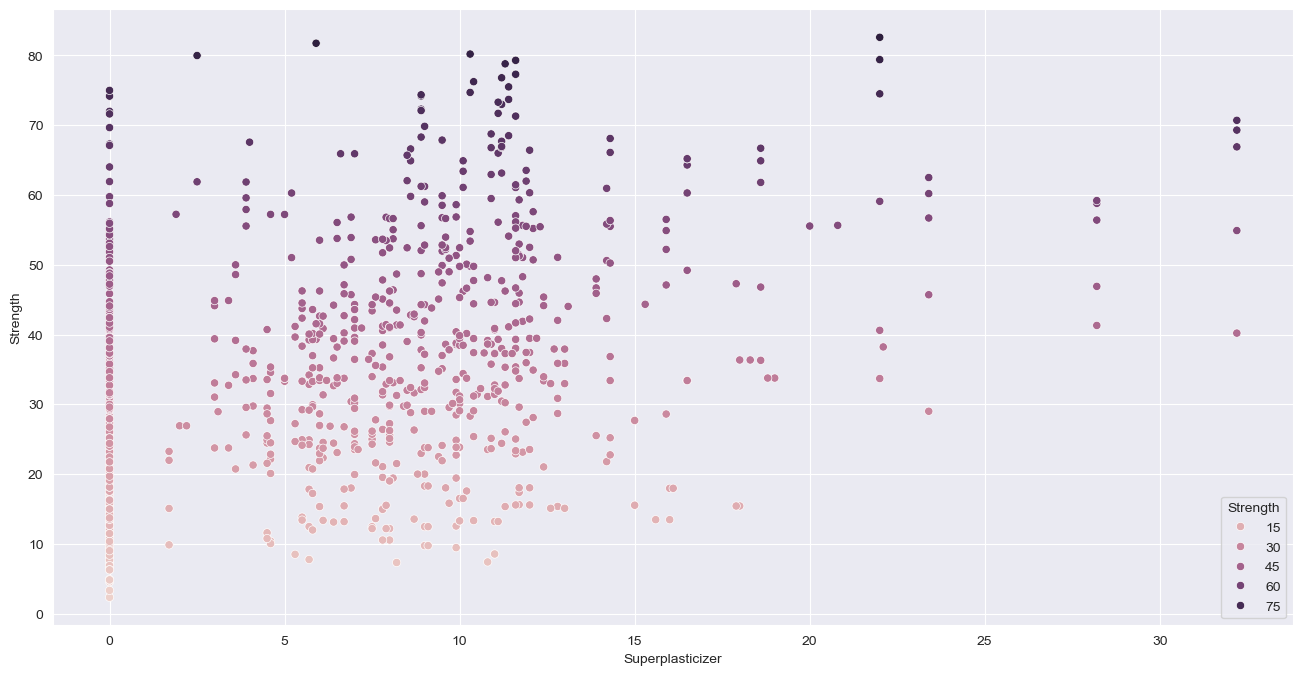

In [493]:
sns.scatterplot(
    data= df,
    x= "Superplasticizer",
    y= "Strength",
    hue= "Strength"
)

plt.show()

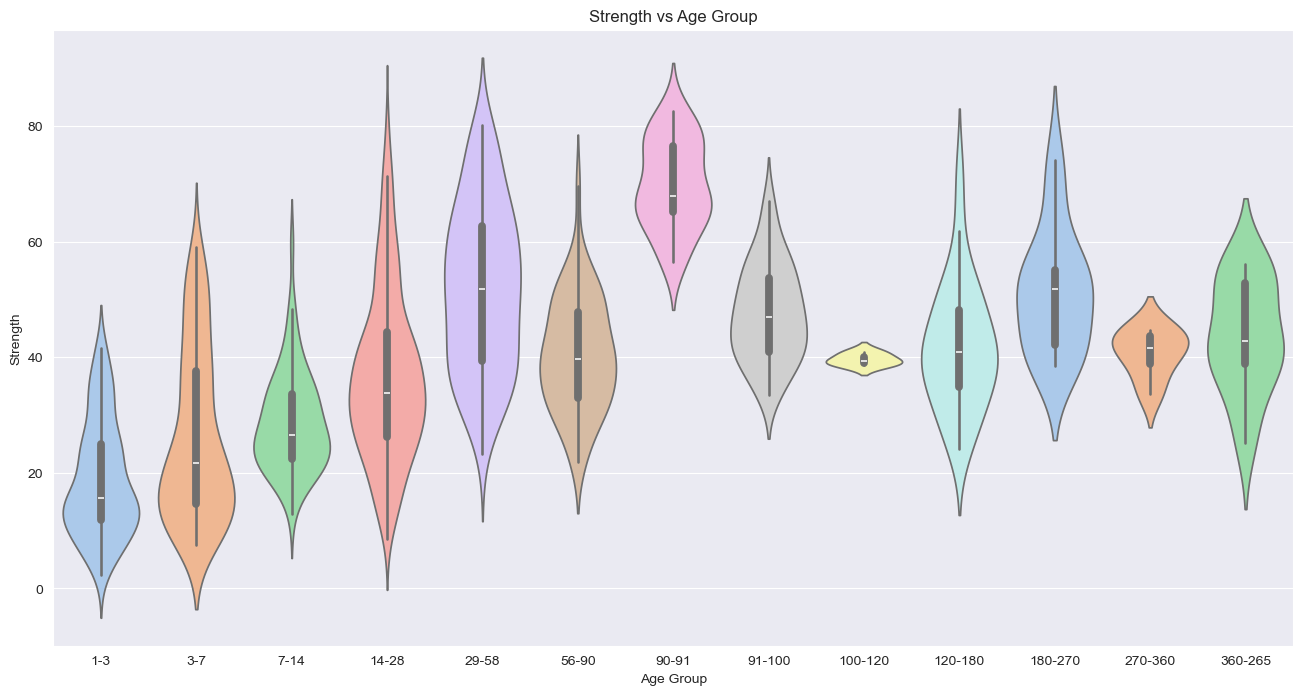

In [557]:
age_bins = [1, 3, 7, 14, 28, 56, 90, 91, 100, 120, 180, 270, 360, 365]
labels = ["1-3", "3-7", "7-14", "14-28", "29-58", "56-90", "90-91", "91-100", "100-120", "120-180", "180-270", "270-360", "360-265"]


df["Age_Group"] = pd.cut(
    df["Age"],
    bins= age_bins,
    labels= labels,
    include_lowest= True
)

sns.violinplot(
    data= df,
    x = "Age_Group",
    y = "Strength",
    palette= "pastel"
)

plt.title("Strength vs Age Group")
plt.xlabel("Age Group")

plt.show()

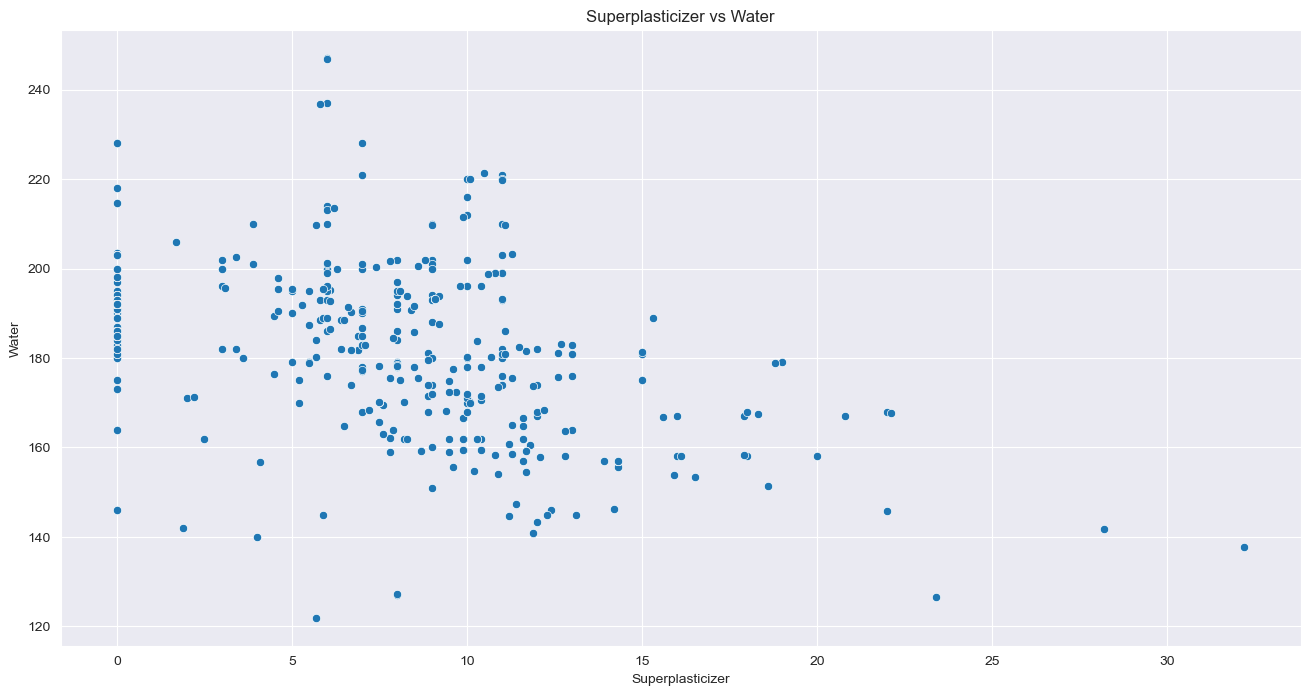

In [558]:
sns.scatterplot(
    data= df,
    x= "Superplasticizer",
    y= "Water"
)

plt.title("Superplasticizer vs Water")

plt.show()

In [496]:
df["Water_Cement_Ratio"] = df["Water"] / df["Cement"]

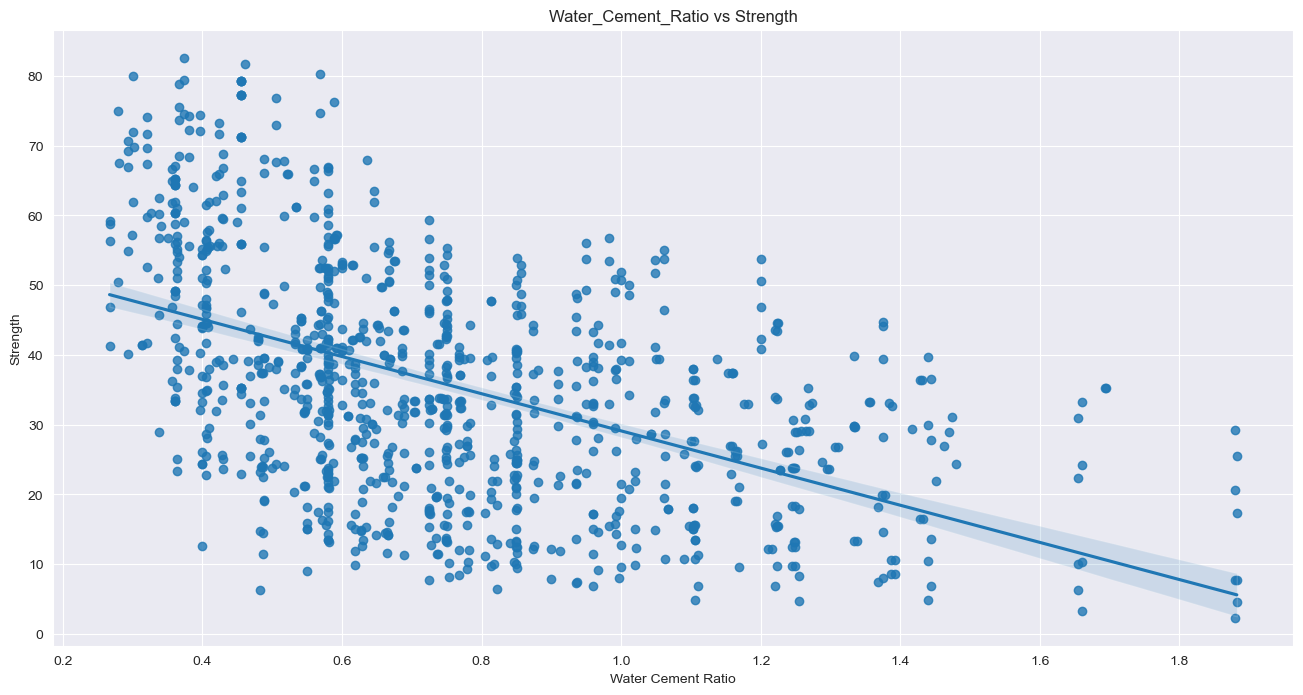

In [560]:
sns.regplot(
    data= df,
    x= "Water_Cement_Ratio",
    y= "Strength"
)

plt.title("Water_Cement_Ratio vs Strength")
plt.xlabel("Water Cement Ratio")
plt.show()

In [498]:
# Çıkarımlar

# Değişkenin dağılımı, normal dağılıma yakın bir dağılıma göstermektedir.

# Gözlerimer dağılımın merkezi etrafında yoğunlaşmaktadır.

# Az sayıda Aykırı Değer tespit edilmiştir.

# Dağılımda az sayıda bulunan büyük değerler, dağılımın sağ tarafında kısa bir kuyruğa sebep olmuştur.
# bu durum değişkende hafif pozitif(sağa) çarpıklık olduğunu göstermektedir

# Cement(Çimento) değişkeninde gözlerimlerin büyük çoğunluğu düşük ve orta değerlerde yoğunlaşkmakta olup
# yüksek değerlere sahip az sayıdaki gözlem dağılımında hafif sağa çarpıklığa sebepl olmaktadır

# Water(Su) değikeninde değerler belirli bir aralıkta yoğunlaşmış olup dapılımda hafif sağa kayma bulunmaktadır.

# Age(Yaş) değişkeninde değerler dağılımın solunda düşük değerlerde yoğunlaşmış olup az sayıdaki yüksek değerler dağılımın sağ tarafında uzun bir kuyruk oluşturmuştur.
# bu durum değişken dağılımınım aşırı sağa çarpık olduğunu göstermektedir.

# Water/Cement orani ile Strength arasında güçlü negatif ve doğrusal olmayan bir ilişki gözlemlenmiştir.
# Dağılım Water/Cement oranı arttıkça beton direncinin azaldığını göstermektedir.
# Dağılıımın eğrisel oluşu, doğrusal modellerin örüntüyü öğrenmede sınırlı kalabileceğini göstermektedir. 


## Preprocessing

In [499]:
from sklearn.preprocessing import StandardScaler

In [500]:
scaler = StandardScaler()

In [501]:
X = df.drop(["Strength", "Age_Group"], axis = 1)
y = df["Strength"]

In [502]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [503]:
feature_names = X_train.columns

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# GradientBoost gibi Tree Based öğrenme algoritmaları feature scaling'e ihtiyaç duymaz.
# Buradaki amaç,ön işleme yöntem ve bilgisini tekrar etmek amacıyla eklenmiştir.

## Training

In [504]:
# Temel model eğitiminin yapılması.

In [505]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.model_selection import cross_val_score, KFold

In [506]:
regressor = GradientBoostingRegressor(random_state= 42)

In [507]:
def evaluate_model(X_train, X_test, y_train, y_test, model, params= None):
    model.fit(X_train, y_train)

    predicts = model.predict(X_test)
    
    if isinstance(model, (GridSearchCV, RandomizedSearchCV)):
        print(model.best_estimator_)
        print(model.best_params_ )


    print(f"\nR2 score : {r2_score(y_test, predicts):.2%}")
    print(f"MSE : {mean_squared_error(y_test, predicts)}")
    print(f"MAE : {mean_absolute_error(y_test, predicts)}")

    def get_predictions():
        return predicts

    return model

In [508]:
model = evaluate_model(X_train, X_test, y_train, y_test, regressor)


R2 score : 89.18%
MSE : 27.868325839369813
MAE : 3.883907550292038


In [509]:
X_cv = df.drop(["Strength", "Age_Group"], axis = 1)
y_cv = df["Strength"]

In [510]:
cv = KFold(
    n_splits= 5,
    shuffle= True,
    random_state= 42
)

scores = cross_val_score(
    estimator= regressor,
    X = X,
    y = y,
    cv= cv,
    scoring= "r2"
)

print("Fold skorları:")
for i, score in enumerate(scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(scores)
print(f"Ortalama R²: {scores.mean():.4f}")
print(f"Standart Sapma: {scores.std():.4f}")

Fold skorları:
Fold 1: 0.8918
Fold 2: 0.8991
Fold 3: 0.9162
Fold 4: 0.9115
Fold 5: 0.9173
[0.89184779 0.89909085 0.916216   0.91151751 0.91729267]
Ortalama R²: 0.9072
Standart Sapma: 0.0100


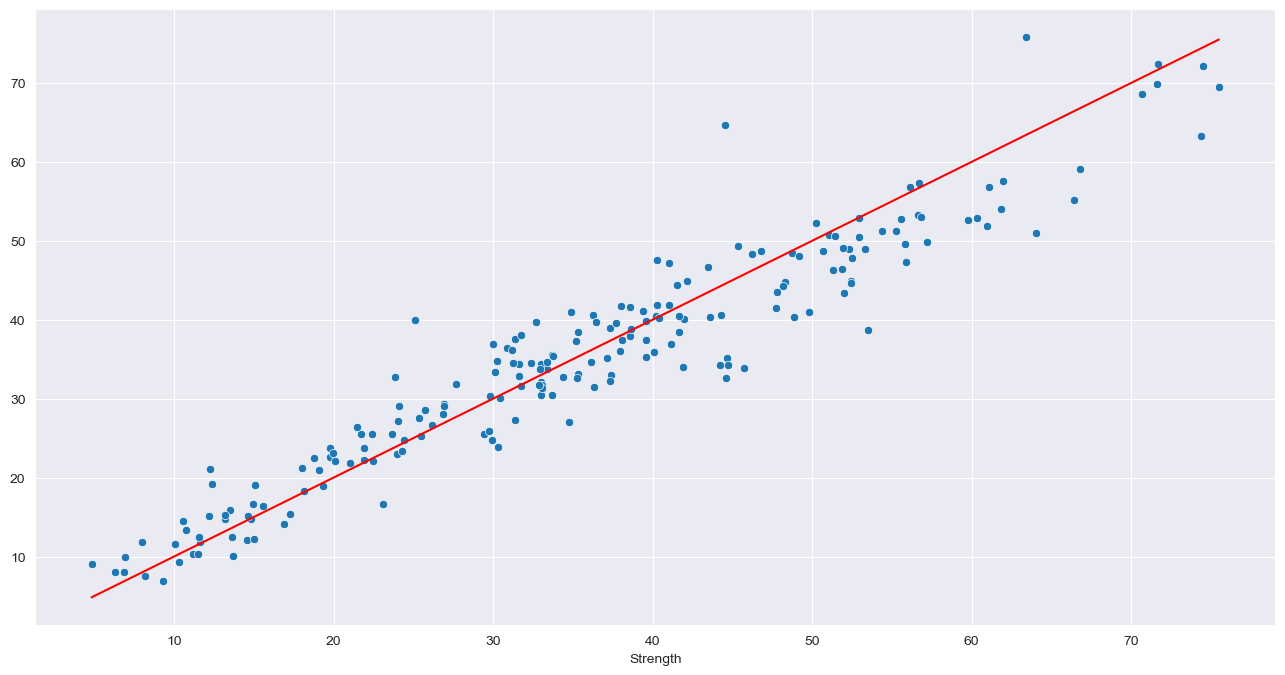

In [511]:
predicts = model.predict(X_test)

plt.figure(figsize= (16, 8))
sns.scatterplot(x= y_test, y= predicts)
sns.lineplot(x= [y_test.min(), y_test.max()], y= [y_test.min(), y_test.max()], color = "red")
plt.show()

In [512]:
# Hedef değişkene Karekök dönüşümü uygulanması ve ardından model eğitiminin yapılması.

In [513]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)


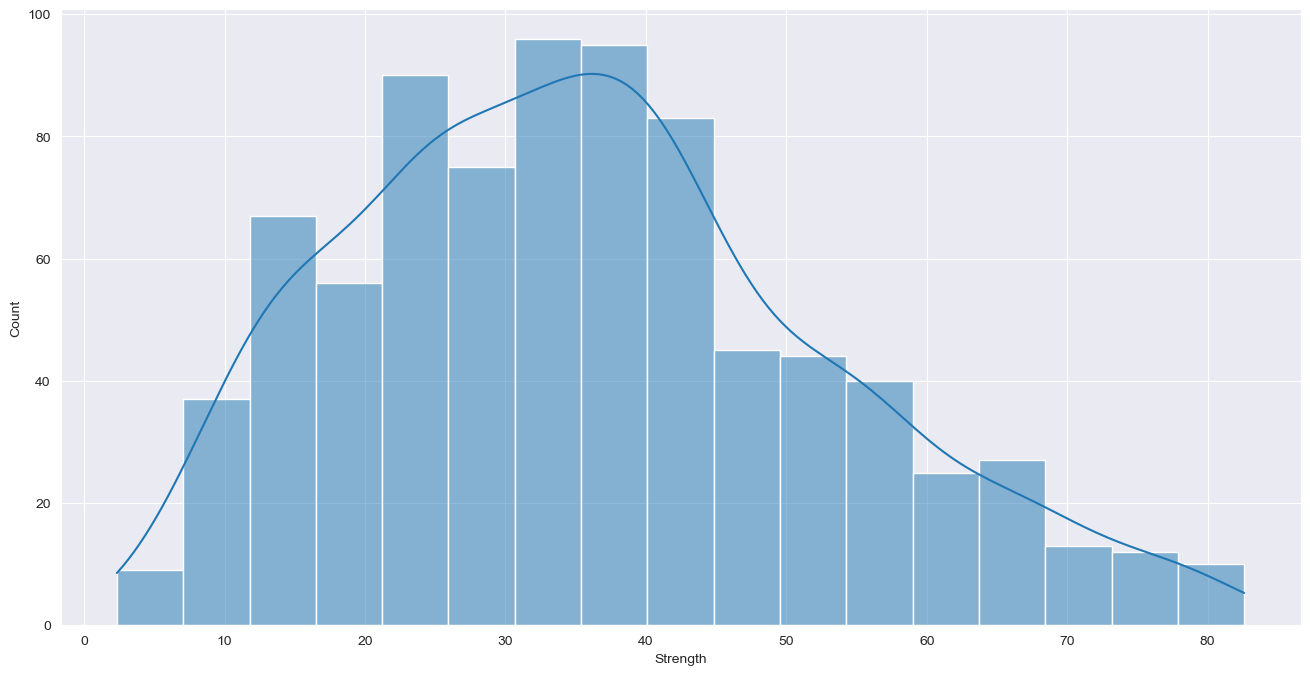

In [514]:
sns.histplot(y_train, kde = True)

plt.show()

In [515]:
y_train.skew()

0.4619332841174562

In [516]:
y_train_sqrt = np.sqrt(y_train)
y_test_sqrt = np.sqrt(y_test)

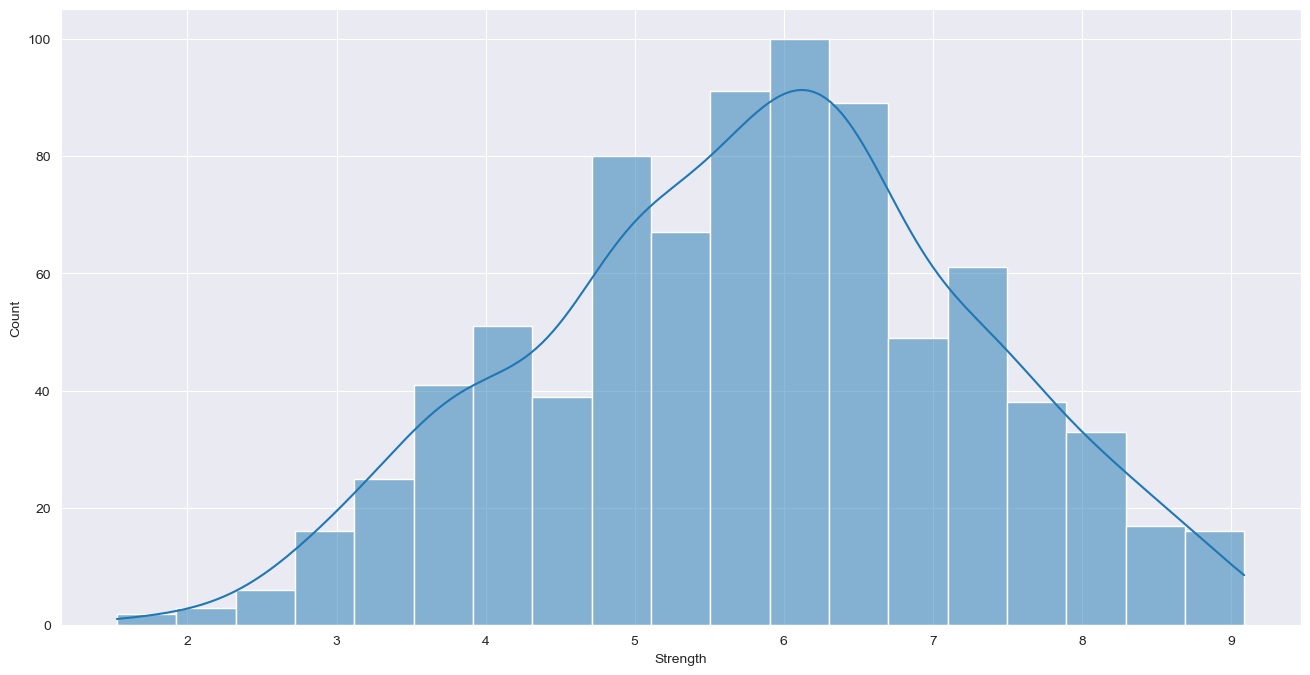

In [517]:
sns.histplot(y_train_sqrt, kde = True)

plt.show()

In [518]:
y_train_sqrt.skew()

-0.11536781175342861

In [519]:
evaluate_model(X_train, X_test, y_train_sqrt, y_test_sqrt, regressor)


R2 score : 91.26%
MSE : 0.17725873425500835
MAE : 0.3273941500761321


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [520]:
scoring = cross_val_score(
    estimator= regressor,
    X= X,
    y= y
)

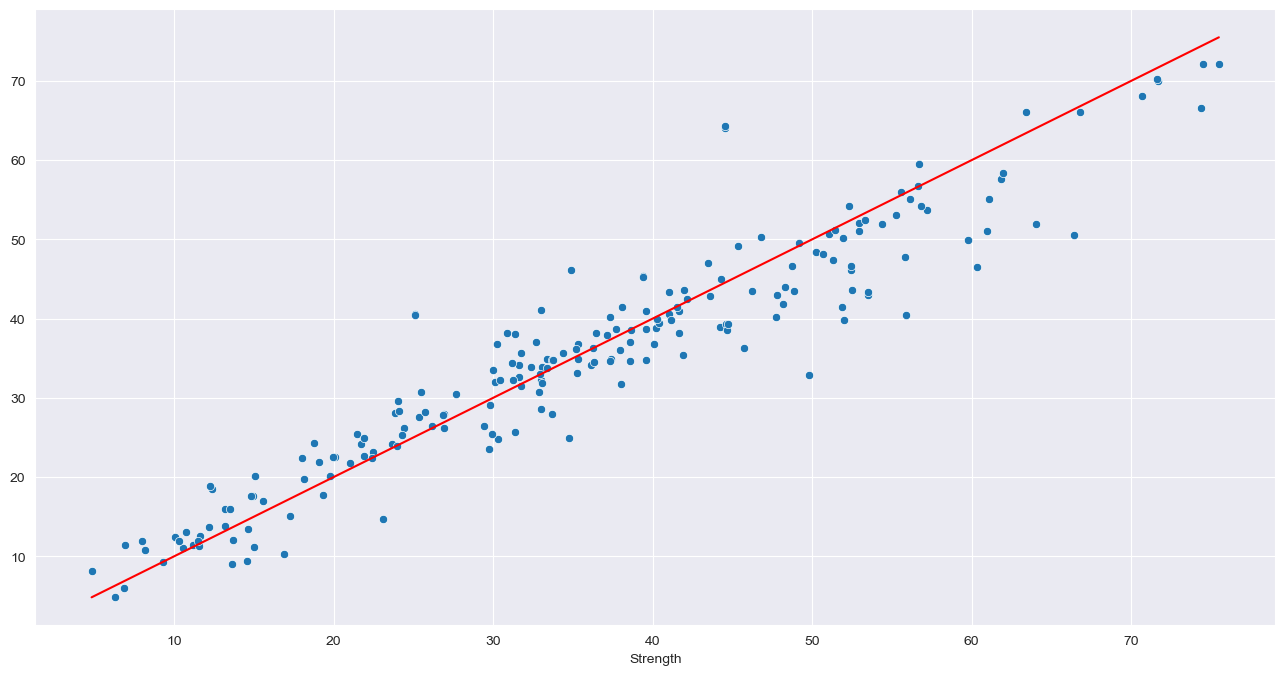

In [533]:
predicts = model.predict(X_test)

plt.figure(figsize= (16, 8))
sns.scatterplot(x= y_test, y= predicts)
sns.lineplot(x= [y_test.min(), y_test.max()], y= [y_test.min(), y_test.max()], color = "red")
plt.show()

In [521]:
# Graident Boosting algoritması eğitiminde Zayıf Öğreniciler(Weak Learners) kullanılır.
# Eğitimde bitden fazla Zayıf Öğrenici olarak sığ Decision Tree kullanılır.

# Her itersayonda yeni bir Tree eğitileceği zaman önceki iterasyondaki Tree'nin Artık değerleri(Residuals)
# öğrenmeye çalışır.

# Böylece her yeni ağaç bir önceki ağaçların eksikliklerini düzeltmiş olur.

# Karekök dönüşümünden sonra değerler sıkıştığı için modelin aşırı büyük hedef değerlerine duyarlılığı azalabilir.
# Bu durum bazı veri setlerinde(şuanda üzerinde çalıştığımız veri setinde olduğu gibi) modelin daha iyi öğrenmesine
# yardımcı olabilir.

## Training with Hyperparameters

In [522]:
regressor = GradientBoostingRegressor(random_state= 42)

In [523]:
params  = {
    "loss" : ['squared_error', 'absolute_error'],
    "learning_rate" : [0.01, 0.1, 1, 3, 5],
    "n_estimators" : [50, 100, 150, 200 ,300, 500],
    "min_samples_split" : [2, 3, 5],
    "max_depth" : [1, 3, 4, 5],
    "max_features" : ['sqrt', 'log2']
}

In [524]:
grid = GridSearchCV(
    estimator= regressor,
    param_grid= params,
    scoring= "r2",
    n_jobs= -1
)

In [525]:
model = evaluate_model(X_train, X_test, y_train_sqrt, y_test_sqrt, grid)

GradientBoostingRegressor(max_features='sqrt', min_samples_split=3,
                          n_estimators=500, random_state=42)
{'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_split': 3, 'n_estimators': 500}

R2 score : 95.06%
MSE : 0.10021906160845355
MAE : 0.2348134483067148


In [526]:
feature_names = feature_names
feature_importance = model.best_estimator_.feature_importances_

importance_df = pd.DataFrame({
    "Feature" : feature_names,
    "Importance" : feature_importance
}).sort_values(by= "Importance", ascending= False).reset_index(drop= True)

importance_df

,Feature,Importance
0,Age,0.4045
1,Water_Cement_Ratio,0.1937
2,Cement,0.1261
3,Water,0.0796
4,Blast Furnace Slag,0.0603
5,Superplasticizer,0.0429
6,Fine Aggregate,0.0389
7,Coarse Aggregate,0.0274
8,Fly Ash,0.0265


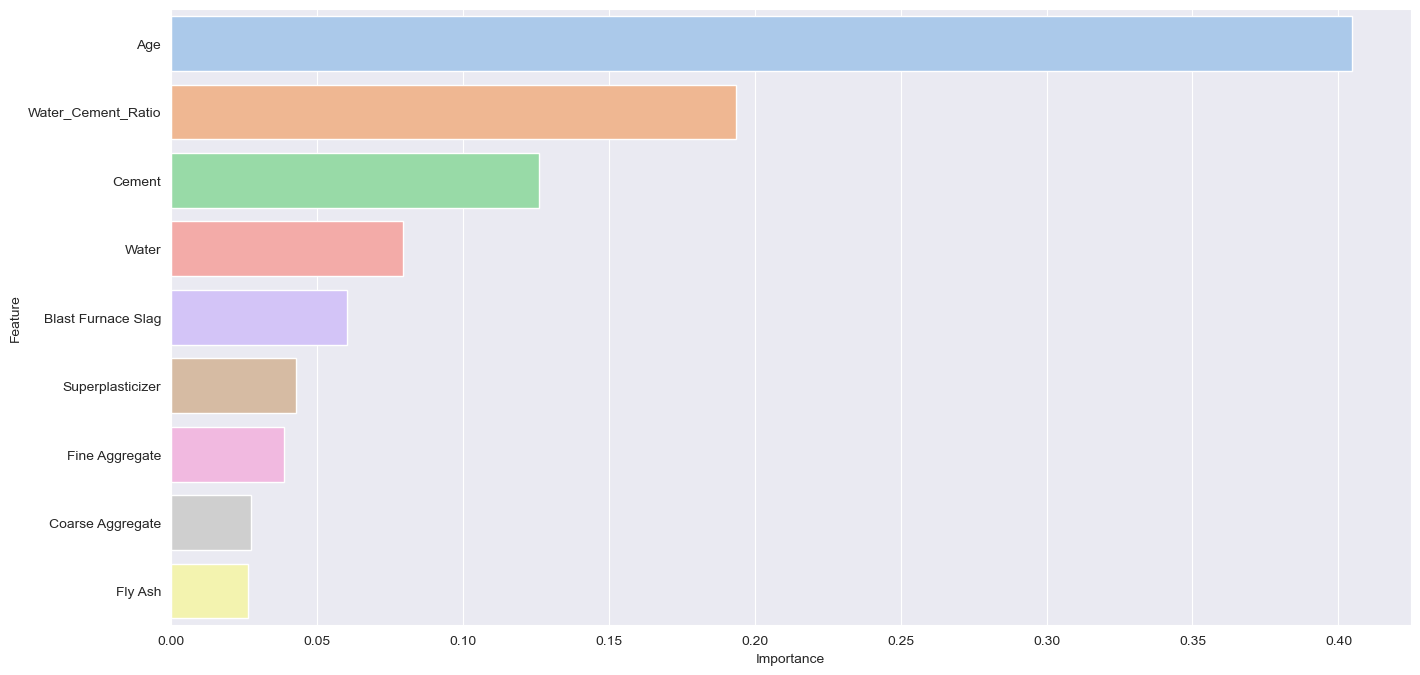

In [527]:
ax = sns.barplot(
    data= importance_df,
    y=  "Feature",
    x = "Importance",
    palette= "pastel"
)

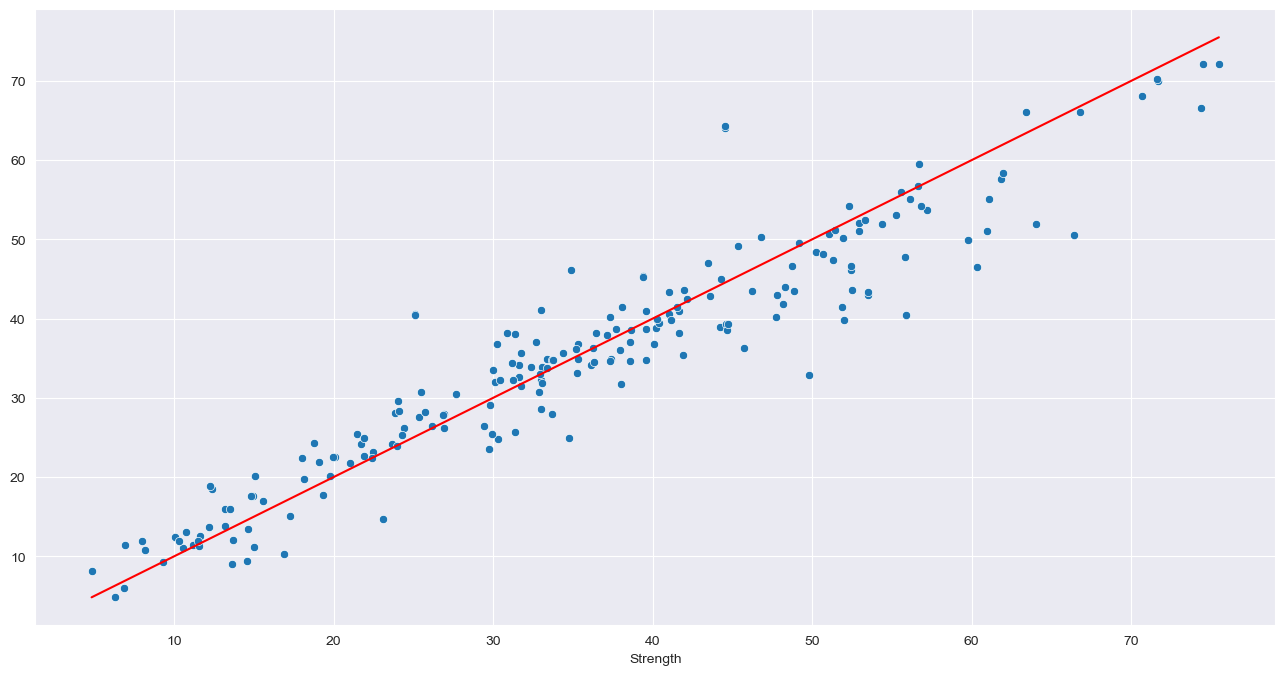

In [535]:
y_true = np.square(y_test_sqrt)

predicts = model.predict(X_test)

plt.figure(figsize= (16, 8))
sns.scatterplot(x= y_test, y= predicts)
sns.lineplot(x= [y_true.min(), y_true.max()], y= [y_true.min(), y_true.max()], color = "red")
plt.show()

## Model Comparison

In [528]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor

In [550]:
models = [LinearRegression(), Ridge(random_state= 42), Lasso(random_state= 42), SVR(), DecisionTreeRegressor(random_state= 42), KNeighborsRegressor(), AdaBoostRegressor(random_state= 42), RandomForestRegressor(random_state= 42)]

In [551]:
scores = []
names = []
for model in models:
    print("=" * 60)
    print(type(model).__name__)
    model = evaluate_model(X_train, X_test, y_train, y_test, model= model)
    scores.append(model.score(X_test, y_test))
    names.append(type(model).__name__)
    print("=" * 60)


LinearRegression

R2 score : 63.26%
MSE : 94.65937978904012
MAE : 7.638487330481421
Ridge

R2 score : 63.24%
MSE : 94.7261504512569
MAE : 7.644507292179475
Lasso

R2 score : 62.76%
MSE : 95.9593910913831
MAE : 7.743431486232525
SVR

R2 score : 22.20%
MSE : 200.4772769036912
MAE : 11.568443122708032
DecisionTreeRegressor

R2 score : 85.89%
MSE : 36.348498179611646
MAE : 4.031868932038835
KNeighborsRegressor

R2 score : 73.70%
MSE : 67.76205679611651
MAE : 6.442281553398059
AdaBoostRegressor

R2 score : 76.57%
MSE : 60.3832540259543
MAE : 6.307241633252997
RandomForestRegressor

R2 score : 89.09%
MSE : 28.10850238880661
MAE : 3.686297991215902


In [552]:
models = pd.DataFrame({
    "Model" : names,
    "Score" : scores
}).sort_values(by= "Score", ascending= False).reset_index(drop= True)

In [553]:
models

,Model,Score
0,RandomForestRegressor,0.8909
1,DecisionTreeRegressor,0.8589
2,AdaBoostRegressor,0.7657
3,KNeighborsRegressor,0.7370
4,LinearRegression,0.6326
5,Ridge,0.6324
6,Lasso,0.6276
7,SVR,0.2220
